In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import pandas as pdz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from utils import *
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import PROCESSED_DATA_DIR

In [7]:
data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2_H.csv"))

In [8]:
data.shape

(3248, 53)

In [3]:
data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_dataset.csv"))

In [68]:
data['routeType'].unique()

array(['INTERNATIONAL', 'OVERFLIGHT', 'NATIONAL'], dtype=object)

In [71]:
data[data['routeType'] == 'NATIONAL'].shape

(153, 101)

In [72]:
data[data['routeType'] == 'INTERNATIONAL'].shape

(34804, 101)

In [73]:
data[data['routeType'] == 'OVERFLIGHT'].shape

(9938, 101)

In [4]:
pd.set_option('display.max_columns', None)

In [16]:
data["ATOT_track"] = pd.to_datetime(data["ATOT_track"])
data[f"ATOT_track_month"] = data["ATOT_track"].dt.month

C:\Users\jaguevara\AppData\Local\Temp\ipykernel_23452\4011473997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")


<Figure size 1200x600 with 0 Axes>

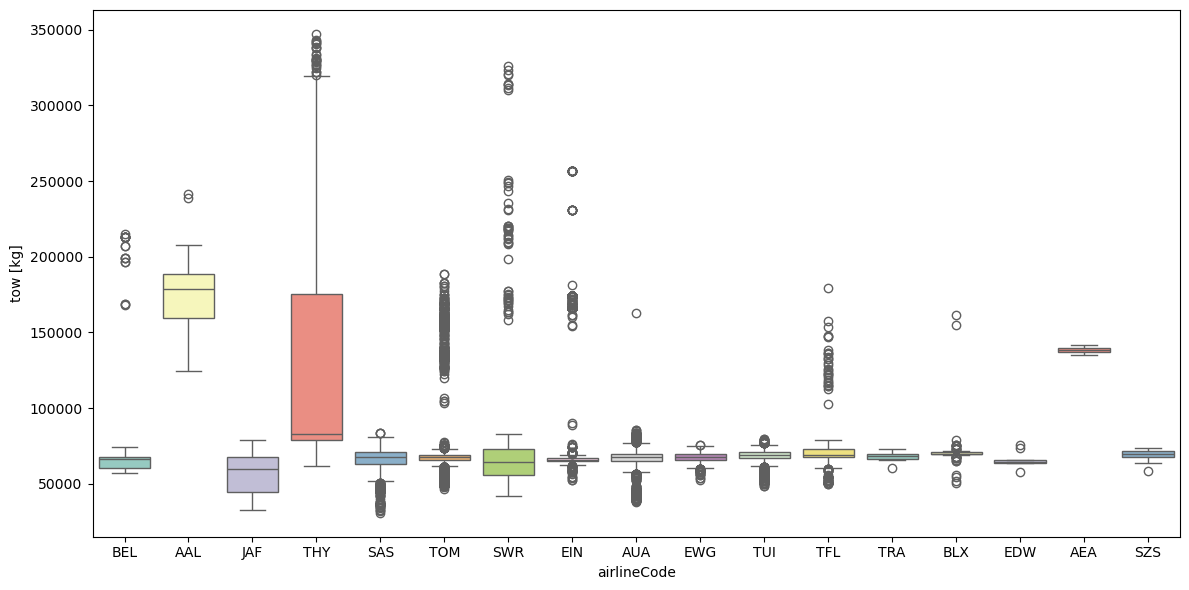

In [31]:
cat_col = 'airlineCode'
plt.figure(figsize=(12, 6))

# Filter the data first
# filtered_data = data[data[cat_col] > 33000]

# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")

# plt.title(f"Distribution of tow over {cat_col}")
# if filtered_data[cat_col].nunique() > 50:
#     plt.xticks([])
# else:
#     plt.xticks(rotation=45)
plt.xlabel(f'{cat_col}')
plt.ylabel('tow [kg]')
plt.tight_layout()
plt.show()

C:\Users\jaguevara\AppData\Local\Temp\ipykernel_23452\1488364689.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")


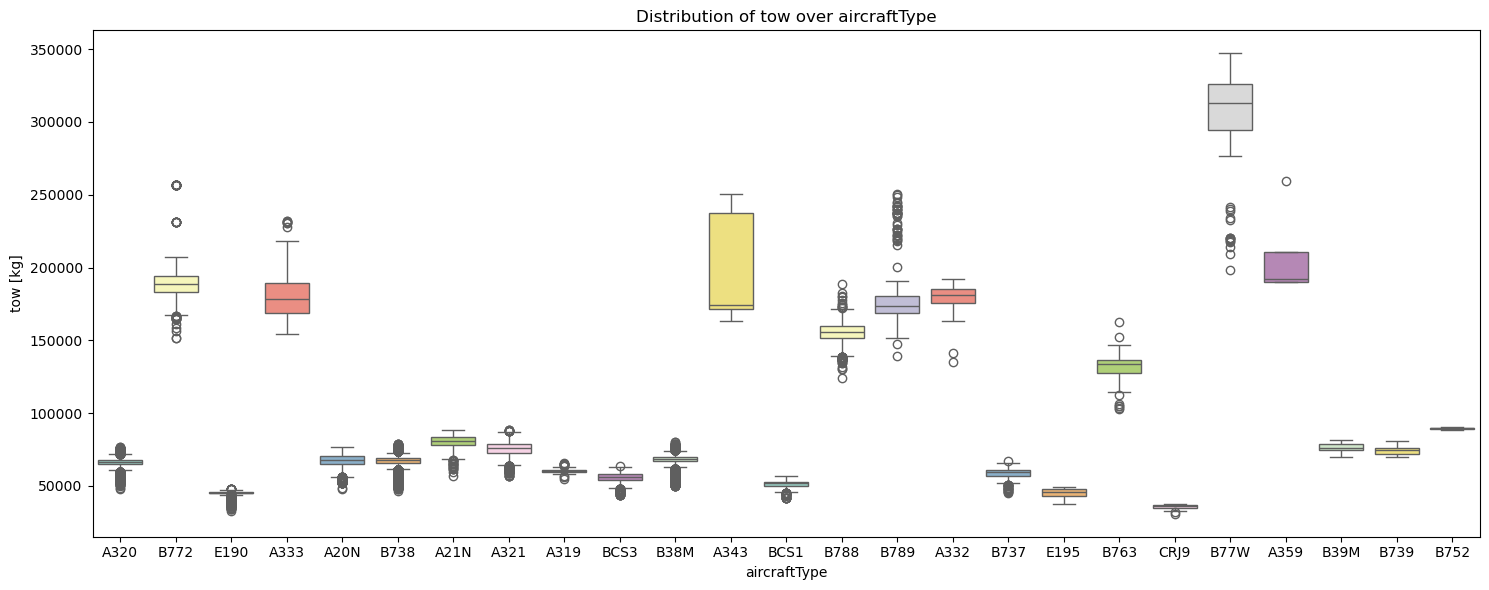

In [33]:
cat_col = 'aircraftType'

# Filter the data first
# filtered_data = data[data[cat_col] > 33000]

# Create the boxplot
plt.figure(figsize=(15, 6))
sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")

plt.title(f"Distribution of tow over {cat_col}")
# if filtered_data[cat_col].nunique() > 50:
#     plt.xticks([])
# else:
#     plt.xticks(rotation=45)
plt.xlabel(f'{cat_col}')
plt.ylabel('tow [kg]')
plt.tight_layout()
plt.show()

C:\Users\jaguevara\AppData\Local\Temp\ipykernel_2916\1813213218.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels)


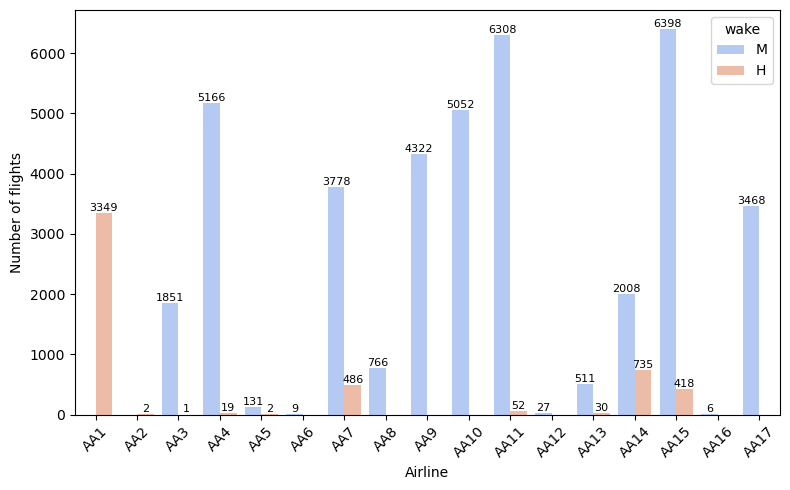

In [64]:
col = 'airlineCode'
hue_col = 'wake'  # or 'wakeTurbulenceCategory' — replace with actual column name
plt.figure(figsize=(8, 5))

# Get unique sorted airline codes
order = sorted(data[col].dropna().unique())

# Generate custom labels: AA1, AA2, ...
custom_labels = [f'AA{i+1}' for i in range(len(order))]

# Create the countplot with specified order
ax = sns.countplot(data=data, x=col, hue=hue_col, order=order, palette="coolwarm")        

# Set axis labels
plt.xlabel('Airline')
plt.ylabel("Number of flights")

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), 
                ha='center', va='bottom', fontsize=8)

# Replace x-tick labels with AA1, AA2, ...
ax.set_xticklabels(custom_labels)
if data[col].nunique() > 50:
    plt.xticks([])
else:   
    plt.xticks(rotation=45)
    
plt.legend(title=hue_col)    
plt.tight_layout()
# plt.show()
plt.savefig('plot.png', transparent=True)

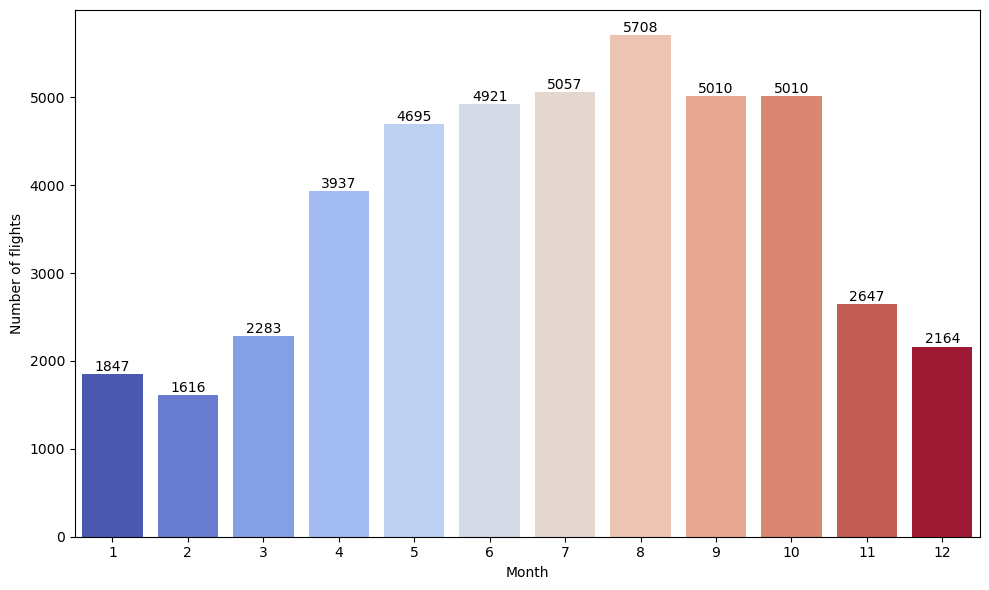

In [24]:
col = 'ATOT_track_month'
plt.figure(figsize=(10, 6))
order = sorted(data[col].dropna().unique())
ax = sns.countplot(data=data, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
# plt.title(f"Distribution of {col}")
plt.xlabel('Month')
plt.ylabel("Number of flights")

# Loop over each patch (bar) and add a text annotation for the count
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), 
            ha='center', va='bottom')

# if data[col].nunique() > 50:
#     plt.xticks([])
# else:
#     plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


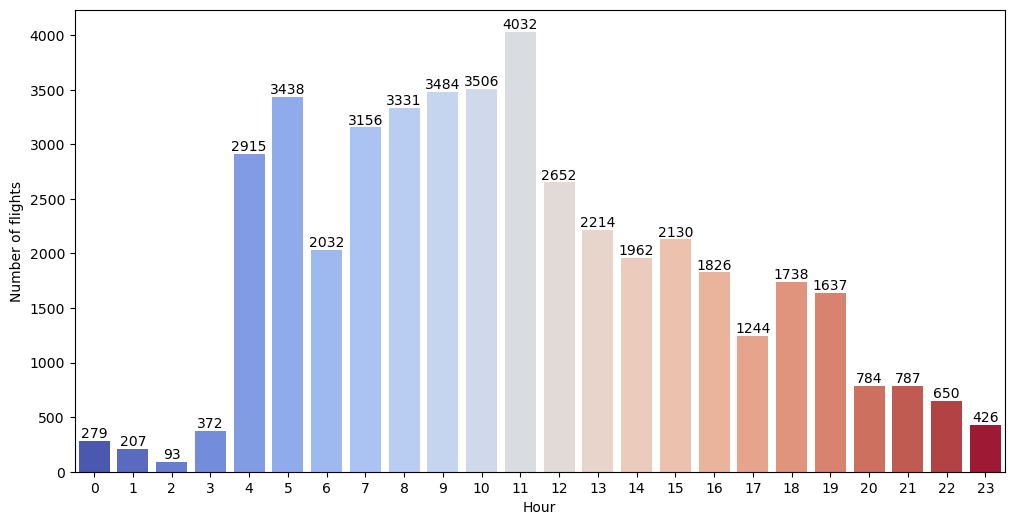

In [27]:
col = 'ATOT_track_hour'
plt.figure(figsize=(12, 6))
order = sorted(data[col].dropna().unique())
ax = sns.countplot(data=data, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
# plt.title(f"Distribution of {col}")
plt.xlabel('Hour')
plt.ylabel("Number of flights")

# Loop over each patch (bar) and add a text annotation for the count
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), 
            ha='center', va='bottom')

# if data[col].nunique() > 50:
#     plt.xticks([])
# else:
#     plt.xticks(rotation=45)
plt.show()


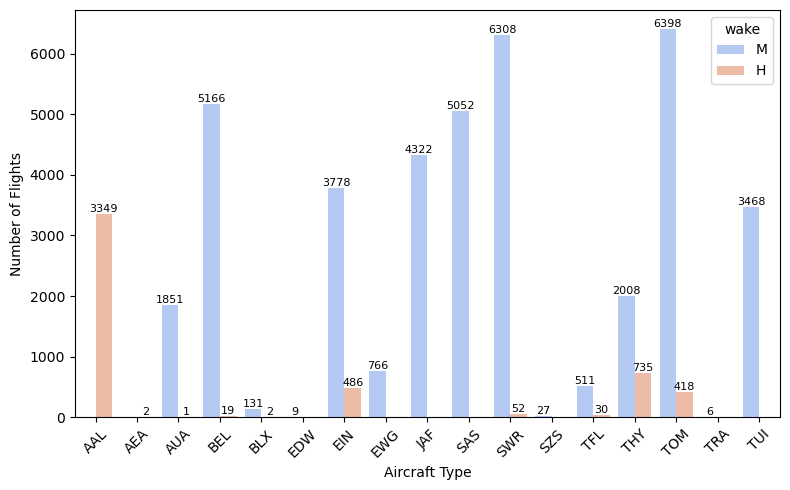

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

col = 'airlineCode'
hue_col = 'wake'  # or 'wakeTurbulenceCategory' — replace with actual column name

plt.figure(figsize=(8, 5))
order = sorted(data[col].dropna().unique())

# Countplot grouped by 'wake'
ax = sns.countplot(data=data, x=col, hue=hue_col, order=order, palette="coolwarm")

plt.xlabel('Aircraft Type')
plt.ylabel("Number of Flights")
# plt.title(f"Distribution of {col} grouped by {hue_col}")

# Annotate bars with counts
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), 
                ha='center', va='bottom', fontsize=8)

# Improve readability if there are many x labels
if data[col].nunique() > 50:
    plt.xticks([])
else:   
    plt.xticks(rotation=45)

plt.legend(title=hue_col)
plt.tight_layout()
# plt.show()
plt.savefig('plot.png', transparent=True)


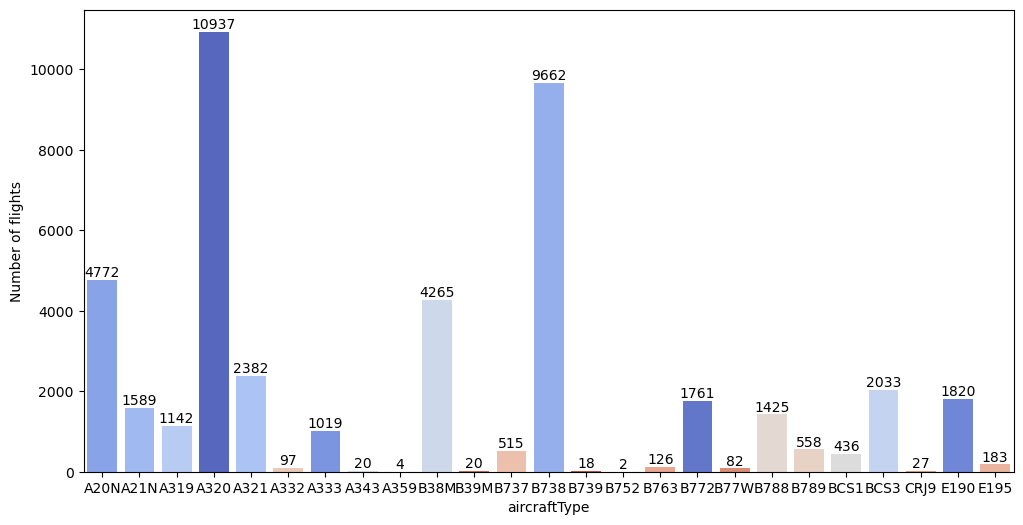

In [18]:
col = 'aircraftType'
plt.figure(figsize=(12, 6))
order = sorted(data[col].dropna().unique())
ax = sns.countplot(data=data, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
# plt.title(f"Distribution of {col}")
plt.xlabel('aircraftType')
plt.ylabel("Number of flights")

# Loop over each patch (bar) and add a text annotation for the count
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), 
            ha='center', va='bottom')

# if data[col].nunique() > 50:
#     plt.xticks([])
# else:
#     plt.xticks(rotation=45)
plt.show()

In [ ]:
def plot_categorical_counts(df, categorical_columns, category_threshold=50):
    for col in categorical_columns:
        plt.figure(figsize=(15, 5))
        order = sorted(df[col].dropna().unique())
        sns.countplot(data=df, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")        
        if df[col].nunique() > category_threshold:
            plt.xticks([])
        else:
            plt.xticks(rotation=45)
        plt.show()


In [51]:
data = data.rename(columns={'mtow_rates': 'mtow_flows'})

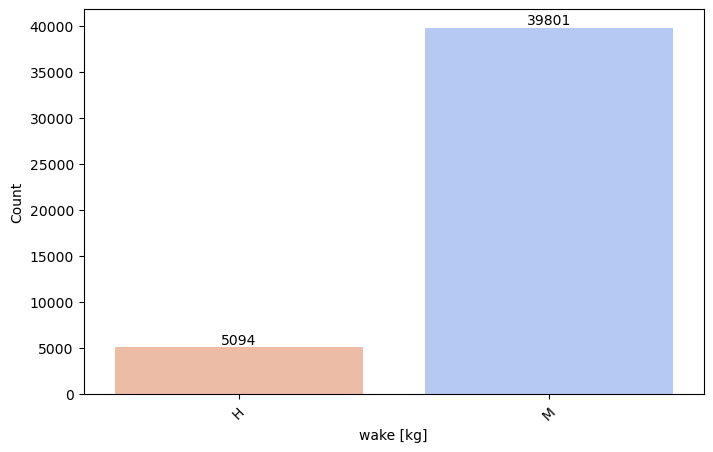

In [15]:
col = 'a'
plt.figure(figsize=(8, 5))
order = sorted(data[col].dropna().unique())
ax = sns.countplot(data=data, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
# plt.title(f"Distribution of {col}")
plt.xlabel(f'{col} [kg]')
plt.ylabel("Count")

# Loop over each patch (bar) and add a text annotation for the count
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), 
            ha='center', va='bottom')

if data[col].nunique() > 50:
    plt.xticks([])
else:
    plt.xticks(rotation=45)
plt.savefig('plot.png', transparent=True)


C:\Users\jaguevara\AppData\Local\Temp\ipykernel_2916\1048678204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")


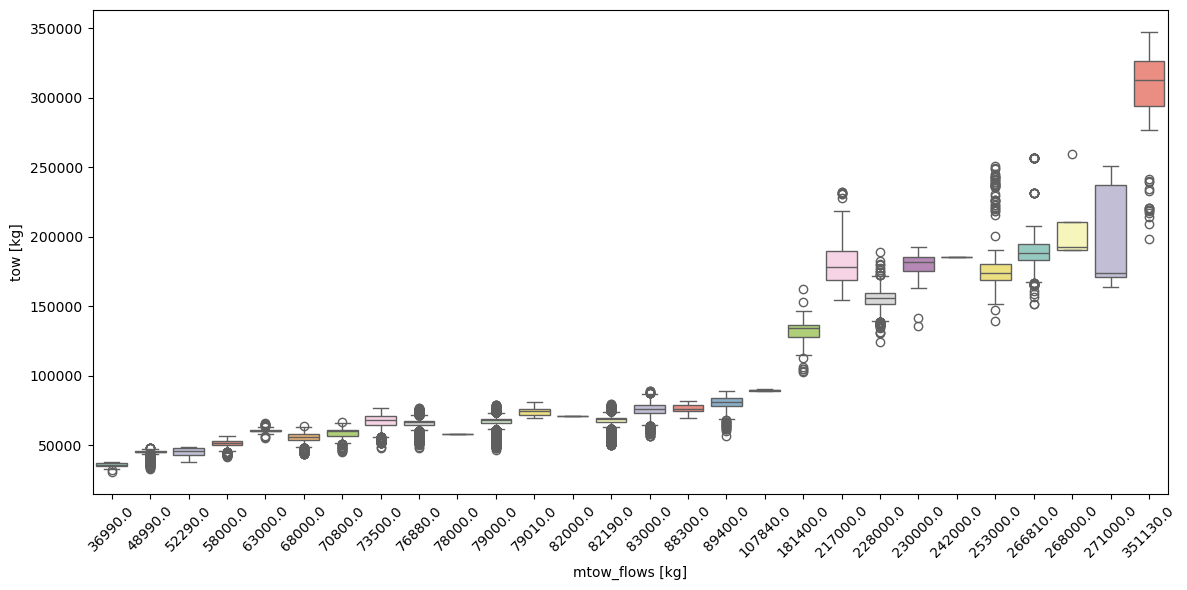

In [74]:
cat_col = 'mtow_rates'
plt.figure(figsize=(12, 6))
sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")

horizontal_line_value = 95000  # Change this to your desired y-value
# plt.axhline(y=horizontal_line_value, color='b', linestyle='--', label=f'Horizontal line at {horizontal_line_value}')

# Add a vertical line at a specified x-value
vertical_line_value = 17.5  # Change this to your desired x-position (index)
# plt.axvline(x=vertical_line_value, color='b', linestyle='--', label=f'Vertical line at index {vertical_line_value}')

# plt.title(f"Distribution of tow over {cat_col}")
if data[cat_col].nunique() > 50:
    plt.xticks([])
else:
    plt.xticks(rotation=45)
plt.xlabel(f'mtow_flows [kg]')
plt.ylabel('tow [kg]')
plt.tight_layout()
plt.savefig('plot.png', transparent=True)
# plt.show()

C:\Users\jaguevara\AppData\Local\Temp\ipykernel_2916\2310360297.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y='tow', data=filtered_data, palette="Set3")


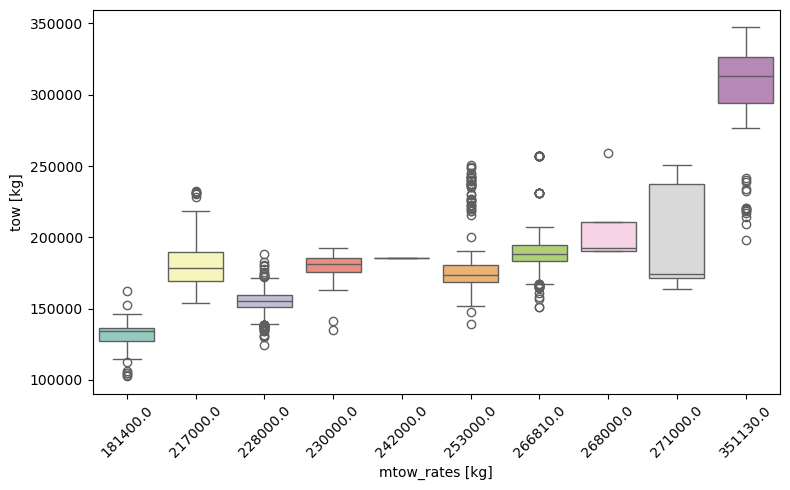

In [62]:
cat_col = 'mtow_rates'
# Filter the data first
filtered_data = data[data[cat_col] >= 181400]

# Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=cat_col, y='tow', data=filtered_data, palette="Set3")

# # Add a horizontal line at a specified y-value
# horizontal_line_value = 90000  # Change this to your desired y-value
# plt.axhline(y=horizontal_line_value, color='b', linestyle='--', label=f'Horizontal line at {horizontal_line_value}')

# Add a vertical line at a specified x-value
# vertical_line_value = 7.5  # Change this to your desired x-position (index)
# plt.axvline(x=vertical_line_value, color='b', linestyle='--', label=f'Vertical line at index {vertical_line_value}')

# plt.title(f"Distribution of tow over {cat_col}")
if filtered_data[cat_col].nunique() > 50:
    plt.xticks([])
else:
    plt.xticks(rotation=45)
plt.xlabel(f'mtow_rates [kg]')
plt.ylabel('tow [kg]')
plt.tight_layout()
# plt.show()
plt.savefig('plot.png', transparent=True)

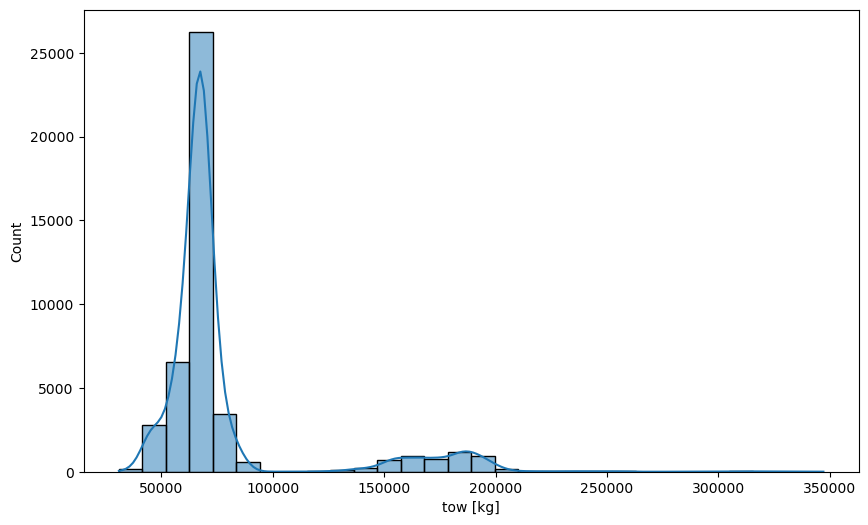

In [44]:
plt.figure(figsize=(10,6))
sns.histplot(data['tow'], kde=True, bins=30)
# plt.title("TOW Distribution")
plt.xlabel("tow [kg]")
plt.ylabel("Count")
plt.show()